#Exercise Question
#1.
##Perform hyperparameter tuning for both the RNN and LSTM models by adjusting parameters such as learning rate = 0.001, batch size = 64, and the number of hidden units = 4 4. Additionally, introduce regularization techniques like dropout = 0.2 and L2 regularization to both models.
#2.
##Evaluate the RNN and LSTM módels using metrics beyond accuracy, such as precision, recall, and F1-score. Use Confusion Matrix to visualize the performance.
#3.
##plot the he accuracy  and loss ss curves for both the training
and validation sets.

In [1]:
import torch
import numpy as np
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
import matplotlib.pyplot as plt

#LOAD MNIST

In [2]:
from torch.utils.data import random_split

# Define the split ratio (e.g., 80% train, 20% validation)
train_ratio = 0.8
val_ratio = 1 - train_ratio

# Transform to normalize the data
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))  # Normalize to [0, 1] range
])

# Load MNIST training and test datasets
trainset = datasets.MNIST(root='./data', train=True, download=True, transform=transform)
testset = datasets.MNIST(root='./data', train=False, download=True, transform=transform)

# Calculate the sizes of the training and validation sets
train_size = int(train_ratio * len(trainset))
val_size = len(trainset) - train_size

# Split the trainset into training and validation sets
trainset, valset = random_split(trainset, [train_size, val_size])

# DataLoader for batching
trainloader = DataLoader(trainset, batch_size=64, shuffle=True)
testloader = DataLoader(testset, batch_size=64, shuffle=False)

valloader = DataLoader(valset, batch_size=64, shuffle=False) # Create valloader



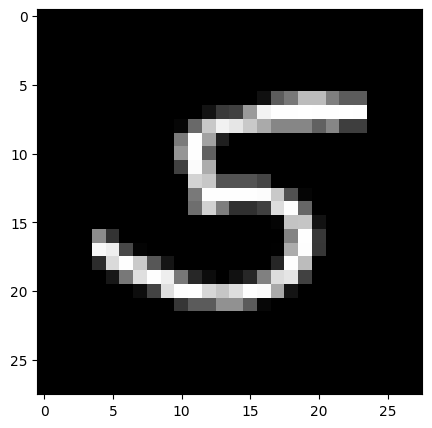

In [3]:
import matplotlib.pyplot as plt
%matplotlib inline

# obtain one batch of training images
dataiter = iter(trainloader)
images, labels = next(dataiter) #common mistake is using dataiter.next() which doesn't work anymore
images = images.numpy()

# get one image from the batch
img = np.squeeze(images[9])

fig = plt.figure(figsize = (5,5))
ax = fig.add_subplot(111)
ax.imshow(img, cmap='gray')

#RNN MODEL

In [4]:
class RNN_Model(nn.Module):
    def __init__(self, input_size=28, hidden_size=128, num_classes=10, num_layers=4, dropout_prob=0.2):
        super(RNN_Model, self).__init__()
        self.rnn = nn.RNN(input_size, hidden_size, num_layers=num_layers, batch_first=True, dropout=dropout_prob)
        self.fc = nn.Linear(hidden_size, num_classes)
        self.dropout = nn.Dropout(dropout_prob) # Dropout layer

    def forward(self, x):
        out, _ = self.rnn(x)
        out = self.dropout(out[:, -1, :]) # Apply dropout before the linear layer
        out = self.fc(out)
        return out

In [5]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [6]:
def train(model, trainloader, criterion, optimizer, device, num_epochs=10):
    model.train()
    train_losses = []
    train_accuracies = []
    for epoch in range(num_epochs):
        running_loss = 0.0
        correct = 0
        total = 0
        for i, data in enumerate(trainloader, 0):
            inputs, labels = data[0].to(device), data[1].to(device)
            optimizer.zero_grad()

            outputs = model(inputs.view(-1, 28, 28))
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            running_loss += loss.item()
            _, predicted = torch.max(outputs.data, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

        epoch_loss = running_loss / len(trainloader)
        epoch_accuracy = 100 * correct / total
        train_losses.append(epoch_loss)
        train_accuracies.append(epoch_accuracy)

        print(f'Epoch {epoch+1}, Loss: {epoch_loss:.4f}, Accuracy: {epoch_accuracy:.2f}%')

    # Plotting the training curves
    import matplotlib.pyplot as plt
    epochs = range(1, 6)
    plt.figure(figsize=(12, 5))

    plt.subplot(1, 2, 1)
    plt.plot(epochs, train_losses, label='Training Loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.title('Training Loss')
    plt.legend()

    plt.subplot(1, 2, 2)
    plt.plot(epochs, train_accuracies, label='Training Accuracy')
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy')
    plt.title('Training Accuracy')
    plt.legend()

    plt.tight_layout()
    plt.show()

    return train_losses, train_accuracies


In [7]:
# Initialize the model, loss function, and optimizer for RNN
rnn_model = RNN_Model().to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(rnn_model.parameters(), lr=0.001, weight_decay=0.001)



Epoch 1, Loss: 0.7233, Accuracy: 75.68%
Epoch 2, Loss: 0.3029, Accuracy: 91.40%
Epoch 3, Loss: 0.2372, Accuracy: 93.28%
Epoch 4, Loss: 0.1999, Accuracy: 94.35%
Epoch 5, Loss: 0.1744, Accuracy: 95.03%


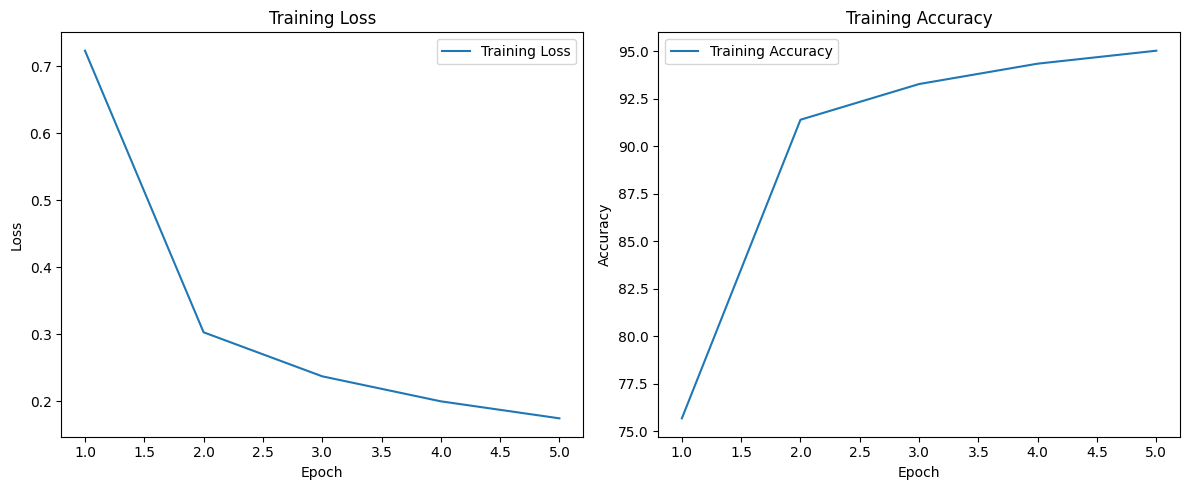

([0.7232712375720342,
  0.3029010778715213,
  0.23719163239498933,
  0.1998507142762343,
  0.17444555685669183],
 [75.67916666666666, 91.39791666666666, 93.27708333333334, 94.35, 95.03125])

In [8]:
# Train the RNN model
train(rnn_model, trainloader, criterion, optimizer, device, num_epochs=5)


In [9]:
def evaluate(model, testloader):
    model.eval()
    y_true = []
    y_pred = []
    with torch.no_grad():
        for images, labels in testloader:
            # Reshape the input to 3D for the RNN
            images = images.view(-1, 28, 28)

            outputs = model(images.to(device)) # move images to the appropriate device
            _, predicted = torch.max(outputs.data, 1)
            y_true.extend(labels.cpu().numpy()) # move labels to cpu before converting to numpy
            y_pred.extend(predicted.cpu().numpy()) # move predictions to cpu before converting to numpy

    # Calculate metrics
    from sklearn.metrics import precision_score, recall_score, f1_score, confusion_matrix
    import seaborn as sns
    precision = precision_score(y_true, y_pred, average='weighted')
    recall = recall_score(y_true, y_pred, average='weighted')
    f1 = f1_score(y_true, y_pred, average='weighted')

    print(f"Precision: {precision:.4f}")
    print(f"Recall: {recall:.4f}")
    print(f"F1-score: {f1:.4f}")

    # Confusion Matrix
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(10, 8))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
    plt.xlabel("Predicted")
    plt.ylabel("True")
    plt.title("Confusion Matrix")
    plt.show()


Precision: 0.9652
Recall: 0.9643
F1-score: 0.9644


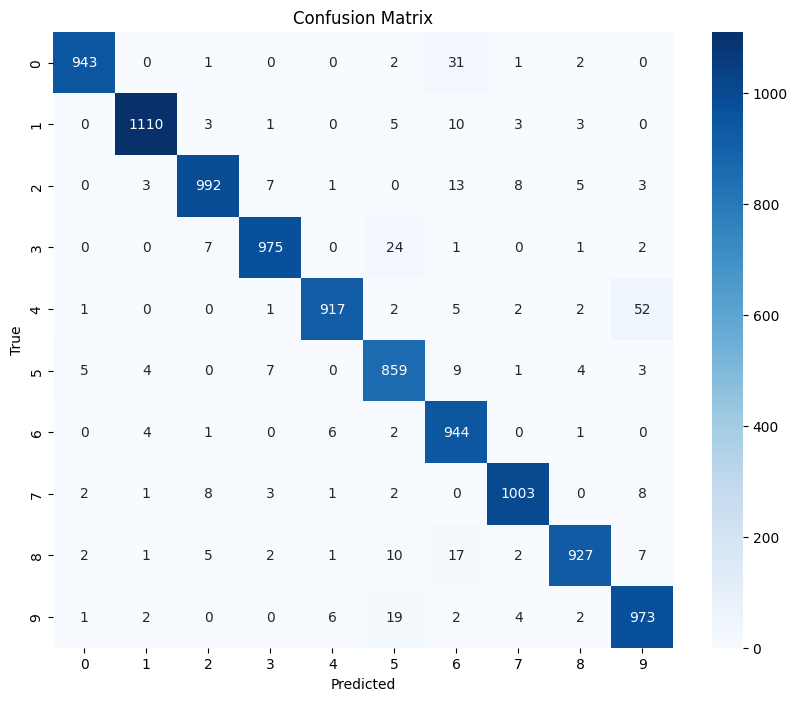

In [10]:
evaluate(rnn_model, testloader)

#LSTM

In [11]:
class LSTM_Model(nn.Module):
    def __init__(self, input_size=28, hidden_size=128, num_layers=2, num_classes=10):
        super(LSTM_Model, self).__init__()

        # LSTM layer
        self.lstm = nn.LSTM(input_size, hidden_size, num_layers, batch_first=True)

        # Fully connected layer
        self.fc = nn.Linear(hidden_size, num_classes)

    def forward(self, x):
        # x: (batch_size, seq_length, input_size) -> (batch_size, 28, 28)

        # LSTM expects input shape (batch, seq_length, input_size)
        lstm_out, (hn, cn) = self.lstm(x)

        # Use the last hidden state to predict the class
        out = self.fc(hn[-1])
        return out


In [12]:
class LSTM_Model(nn.Module):
    def __init__(self, input_size=28, hidden_size=128, num_layers=4, num_classes=10, dropout_prob=0.2):
        super(LSTM_Model, self).__init__()

        # LSTM layer with 4 hidden layers
        self.lstm = nn.LSTM(input_size, hidden_size, num_layers, batch_first=True,  dropout=dropout_prob)

        # Fully connected layer
        self.fc = nn.Linear(hidden_size, num_classes)
        self.dropout = nn.Dropout(dropout_prob)

    def forward(self, x):
        lstm_out, (hn, cn) = self.lstm(x)
        out = self.dropout(lstm_out[:, -1, :])  # Corrected line
        out = self.fc(out)
        return out

Epoch 1, Loss: 0.7950, Accuracy: 72.04%
Epoch 2, Loss: 0.2045, Accuracy: 93.93%
Epoch 3, Loss: 0.1445, Accuracy: 95.73%
Epoch 4, Loss: 0.1163, Accuracy: 96.62%
Epoch 5, Loss: 0.1076, Accuracy: 96.83%


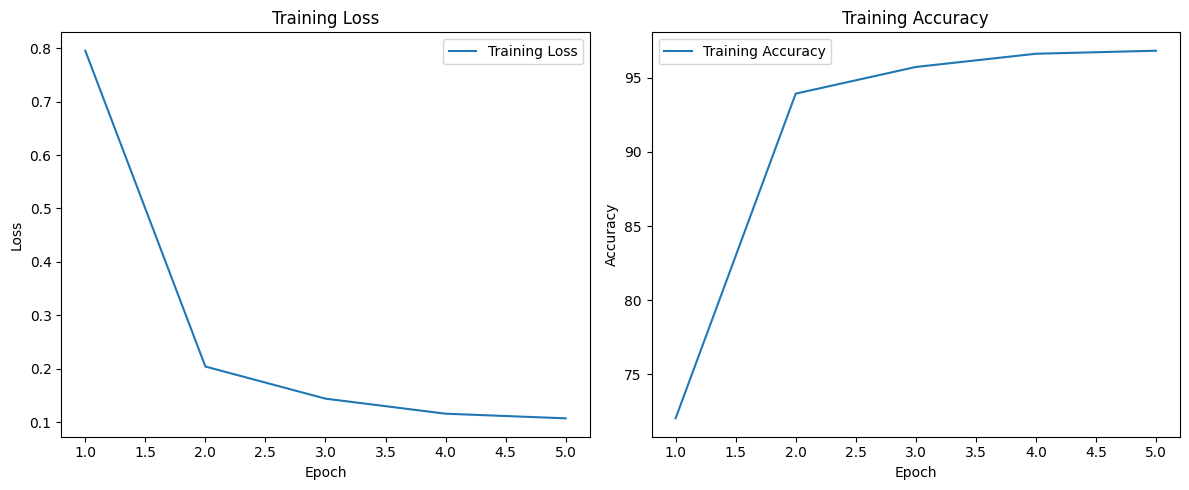

([0.7949969258109728,
  0.2045274017478029,
  0.14445827394227187,
  0.1163322816217939,
  0.10764787355127434],
 [72.04375, 93.93333333333334, 95.73125, 96.62291666666667, 96.82708333333333])

In [13]:
# Initialize the model, loss function, and optimizer for LSTM
lstm_model = LSTM_Model().to(device)
optimizer = optim.Adam(lstm_model.parameters(), lr=0.001, weight_decay=0.001)

# Train the LSTM model
train(lstm_model, trainloader, criterion, optimizer, device, num_epochs=5)


Precision: 0.9652
Recall: 0.9643
F1-score: 0.9644


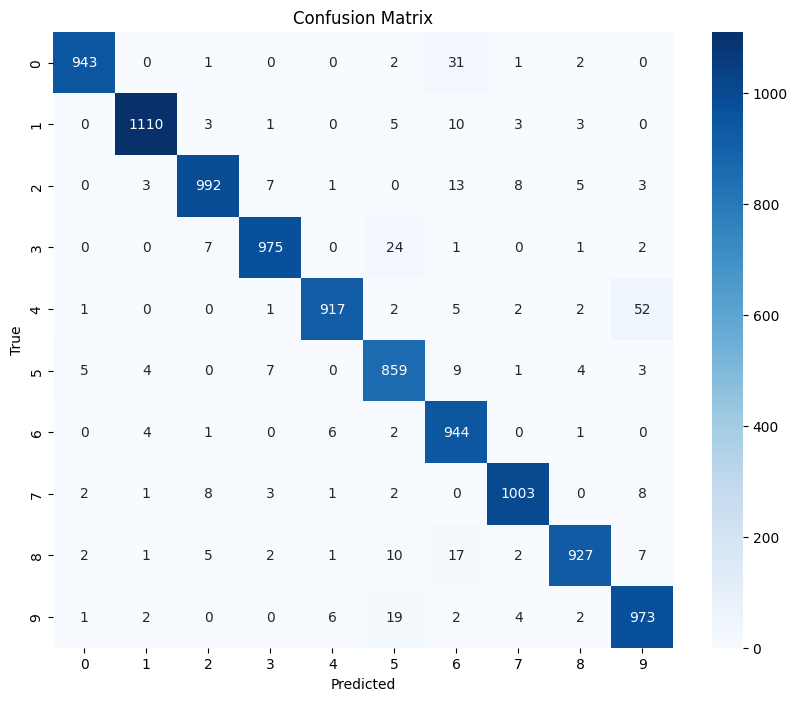

In [14]:
evaluate(rnn_model, testloader)

In [ ]:


def train(model, trainloader, valloader, criterion, optimizer, device, num_epochs=10): # Add valloader as an argument
    model.train()
    train_losses = []
    train_accuracies = []
    val_losses = []
    val_accuracies = []

    for epoch in range(num_epochs):
        running_loss = 0.0
        correct = 0
        total = 0
        for i, data in enumerate(trainloader, 0):
            inputs, labels = data[0].to(device), data[1].to(device)
            optimizer.zero_grad()

            outputs = model(inputs.view(-1, 28, 28))
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            running_loss += loss.item()
            _, predicted = torch.max(outputs.data, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

        epoch_loss = running_loss / len(trainloader)
        epoch_accuracy = 100 * correct / total
        train_losses.append(epoch_loss)
        train_accuracies.append(epoch_accuracy)

        print(f'Epoch {epoch+1}, Loss: {epoch_loss:.4f}, Accuracy: {epoch_accuracy:.2f}%')


        # Validation loop
        model.eval() # Set model to evaluation mode
        val_loss = 0.0
        val_correct = 0
        val_total = 0
        with torch.no_grad():  # Disable gradient calculation for validation
            for data in valloader:  # Iterate over the validation data
                inputs, labels = data[0].to(device), data[1].to(device)
                outputs = model(inputs.view(-1, 28, 28))
                loss = criterion(outputs, labels)
                val_loss += loss.item()
                _, predicted = torch.max(outputs.data, 1)
                val_total += labels.size(0)
                val_correct += (predicted == labels).sum().item()

        val_epoch_loss = val_loss / len(valloader)
        val_epoch_accuracy = 100 * val_correct / val_total
        val_losses.append(val_epoch_loss)
        val_accuracies.append(val_epoch_accuracy)
        print(f'Epoch {epoch+1}, Validation Loss: {val_epoch_loss:.4f}, Validation Accuracy: {val_epoch_accuracy:.2f}%')
    return train_losses, train_accuracies, val_losses, val_accuracies # Return validation metrics


In [ ]:
import matplotlib.pyplot as plt

train_losses, train_accuracies, val_losses, val_accuracies = train(model, trainloader, valloader, criterion, optimizer, device, num_epochs=10)

epochs = range(1, len(train_losses) + 1)

plt.figure(figsize=(12, 5))

# Plot training and validation loss
plt.subplot(1, 2, 1)
plt.plot(epochs, train_losses, label='Training Loss')
plt.plot(epochs, val_losses, label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training and Validation Loss')
plt.legend()

# Plot training and validation accuracy
plt.subplot(1, 2, 2)
plt.plot(epochs, train_accuracies, label='Training Accuracy')
plt.plot(epochs, val_accuracies, label='Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('Training and Validation Accuracy')
plt.legend()

plt.tight_layout()
plt.show()